In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from os import listdir
import matplotlib.pyplot as plt
from pendulibrary.continuation import find_bifurcation, adaptive_cont
from pendulibrary.common_targetters import single_fixed
from pendulibrary.plotters import plot_nu_functions, compare_fast
from pendulibrary.integrate import integrate_state
from pendulibrary.common import hamiltonian
from tqdm.auto import tqdm

In [ ]:
# TODO: remove duplicates, get backwards(backwardes? idk the plural)

In [19]:
fname = "DDsp-B2"

data = np.load(f"../database/{fname}.npz")
x0s_in = data["x0s"]
periods_in = data["periods"]
tangents_in = data["tangents"]
eigs_in = data["eigs"]
Lr, Mr = data["params"]

targ = single_fixed(0, x0s_in[0][0], 3, Lr, Mr, 1e-14)
func = targ.g_dg_stm

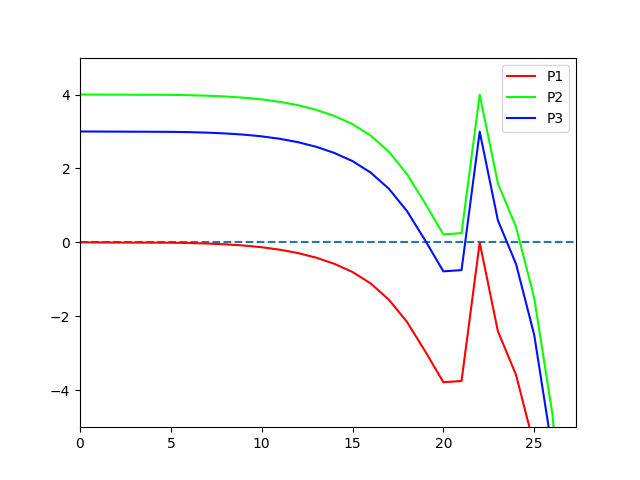

In [35]:
%matplotlib ipympl
fig = plot_nu_functions(eigs_in, 3)
plt.show()

In [39]:
im1 = 26
im0 = 25

Xm0 = targ.get_X(x0s_in[im0], periods_in[im0])
Xm1 = targ.get_X(x0s_in[im1], periods_in[im1])

g, dg, stm = func(Xm1)
svd = np.linalg.svd(dg)
tangent = svd.Vh[-1]
sprev = np.linalg.norm(Xm0 - Xm1)
if np.dot(tangent, Xm0 - Xm1) / sprev < 0:
    tangent *= -1
sprev = np.linalg.norm(Xm0 - Xm1)
print(f"Last dist is {sprev:.3e}")

Last dist is 1.368e-01


In [45]:
X0 = find_bifurcation(
    Xm1,
    func,
    tangent,
    sprev / 5,
    targ_tol=1e-13,
    bisect_tol=1e-13,
    period_mult=1,
    debug=True,
    scale=5,
    seek_local_opt=True,
)

-7.952922101808541 -8.643681356620338 0.027362457692330887
-7.293477288519966 -7.952922101808541 0.027362457692330887
-6.66544800977097 -7.293477288519966 0.027362457692330887
-6.068818584551857 -6.66544800977097 0.027362457692330887
-5.503460110890948 -6.068818584551857 0.027362457692330887
-4.969135803739025 -5.503460110890948 0.027362457692330887
-4.465508091020211 -4.969135803739025 0.027362457692330887
-3.9921474478003858 -4.465508091020211 0.027362457692330887
-3.5485429574075793 -3.9921474478003858 0.027362457692330887
-3.134114599426828 -3.5485429574075793 0.027362457692330887
-2.7482272767045544 -3.134114599426828 0.027362457692330887
-2.3902066037111718 -2.7482272767045544 0.027362457692330887
-2.0593564802184305 -2.3902066037111718 0.027362457692330887
-1.7549784547729135 -2.0593564802184305 0.027362457692330887
-1.476392820144071 -1.7549784547729135 0.027362457692330887
-1.2229612424316603 -1.476392820144071 0.027362457692330887
-0.9941104536985312 -1.2229612424316603 0.027

In [46]:
X1 = X0.copy()
X1[-1] *= 1
g, dg, stm = func(X1)
svd = np.linalg.svd(dg)
tan = svd.Vh[-2]
svd.S

array([5.89865765e+00, 1.04574094e+00, 9.94469580e-06])

In [57]:
cont_kwargs = dict(
    s0=3e-5, s_min=1e-6, S=10.0, tol=1e-11, max_iter=15, target_iter=10, rate=1.05
)
Xs, eig_vals, (DFs, tangents, stms) = adaptive_cont(
    X1, func, tan, **cont_kwargs, exact_tangent=True
)

  0%|          | 0/10.0 [00:00<?, ?it/s]

In [58]:
fnames = [f.removesuffix(".npz") for f in listdir("../database") if f.endswith(".npz")]
x0s_new = np.array([targ.get_x0(X) for X in Xs])
periods_new = np.array([targ.get_period(X) for X in Xs])
compare_fast(periods_new, hamiltonian(x0s_new.T, Lr, Mr), fnames)

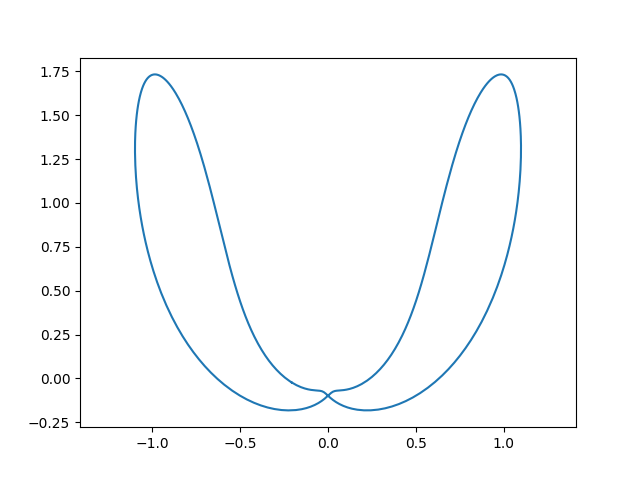

In [59]:
plt.close("all")
ts, xs, fs = integrate_state(x0s_new[-1], periods_new[-1], Lr, Mr, 1e-14)
y = -np.cos(xs[0]) - Lr * np.cos(xs[1])
x = np.sin(xs[0]) + Lr * np.sin(xs[1])

plt.plot(x, y)
plt.axis("equal")
plt.show()

In [86]:
np.savez_compressed(
    "../database/DDsp-P7a",
    x0s=x0s_new,
    periods=periods_new,
    eigs=eig_vals,
    tangents=np.column_stack((np.zeros_like(periods_new), tangents)),
    hamiltonians=hamiltonian(x0s_new.T, Lr, Mr),
    params=np.array([Lr, Mr]),
)